# Task 1: Regression Analysis – CO₂ Emission Prediction

## Objective

The objective of this project is to develop a regression model to predict vehicle CO₂ emissions based on various vehicle characteristics and fuel consumption parameters.

## Domain

Environmental Science and Machine Learning


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv("../dataset/CO2 Emissions_Canada.csv")

df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [11]:
df.shape

(7385, 12)

In [12]:
df.columns

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   str    
 1   Model                             7385 non-null   str    
 2   Vehicle Class                     7385 non-null   str    
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   str    
 6   Fuel Type                         7385 non-null   str    
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: float64(4), in

In [14]:
df.isnull().sum()

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(1103)

In [16]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [17]:
df["CO2 Emissions(g/km)"].describe()

count    7385.000000
mean      250.584699
std        58.512679
min        96.000000
25%       208.000000
50%       246.000000
75%       288.000000
max       522.000000
Name: CO2 Emissions(g/km), dtype: float64

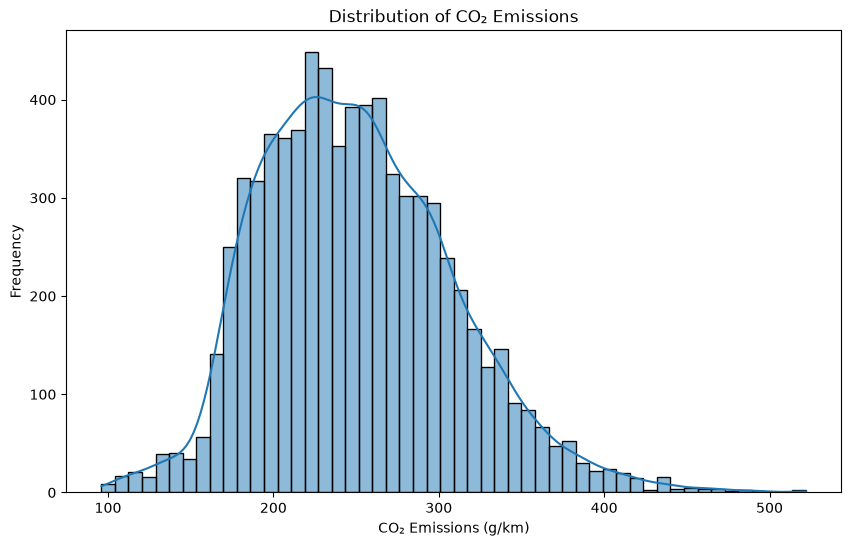

In [18]:
plt.figure(figsize=(10, 6))

sns.histplot(df["CO2 Emissions(g/km)"], kde=True)

plt.title("Distribution of CO₂ Emissions")
plt.xlabel("CO₂ Emissions (g/km)")
plt.ylabel("Frequency")

plt.show()

In [19]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation["CO2 Emissions(g/km)"].sort_values(ascending=False)

CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.919592
Fuel Consumption Comb (L/100 km)    0.918052
Fuel Consumption Hwy (L/100 km)     0.883536
Engine Size(L)                      0.851145
Cylinders                           0.832644
Fuel Consumption Comb (mpg)        -0.907426
Name: CO2 Emissions(g/km), dtype: float64

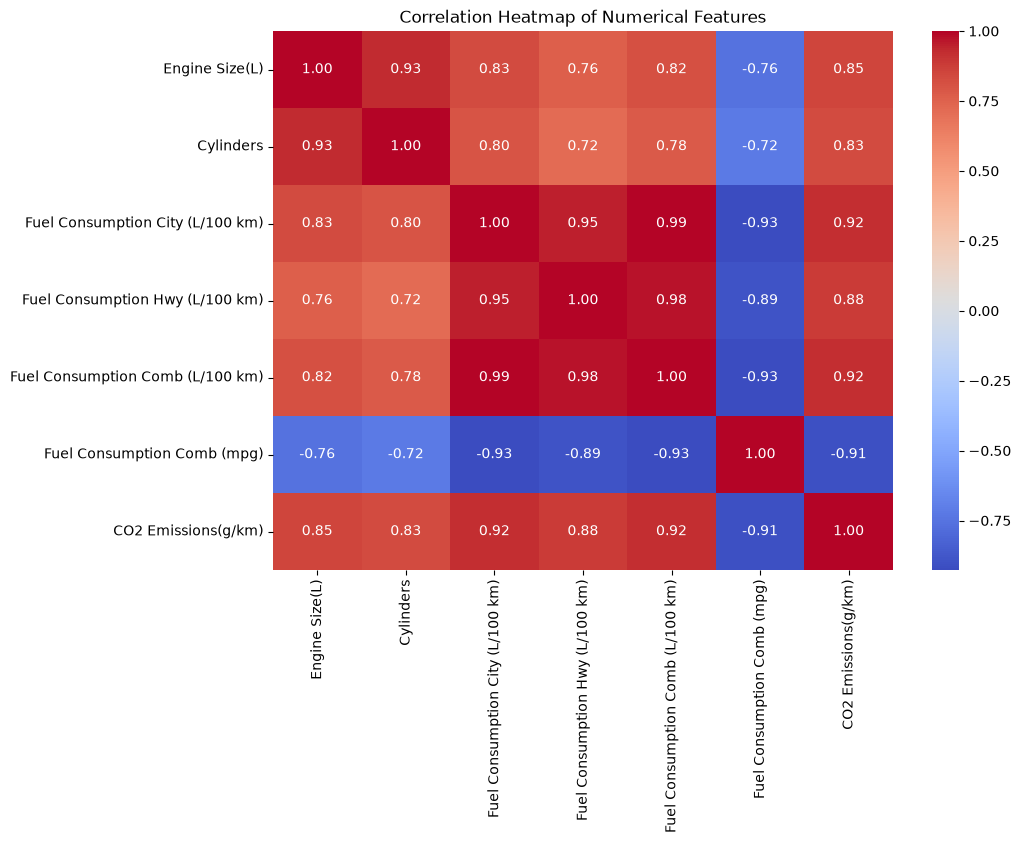

In [21]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

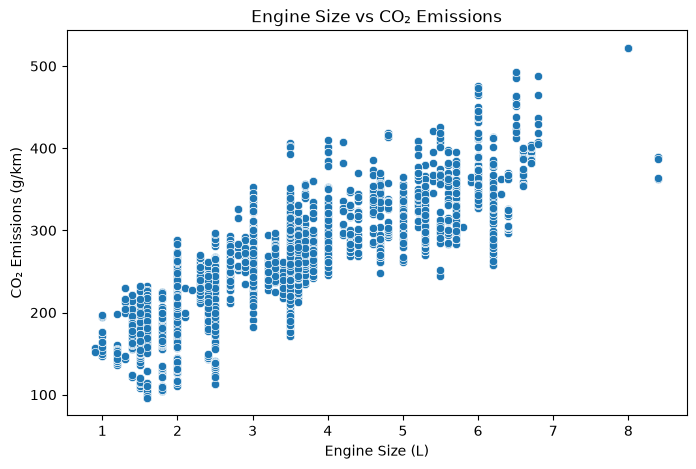

In [22]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Engine Size(L)",
    y="CO2 Emissions(g/km)"
)

plt.title("Engine Size vs CO₂ Emissions")
plt.xlabel("Engine Size (L)")
plt.ylabel("CO₂ Emissions (g/km)")
plt.show()

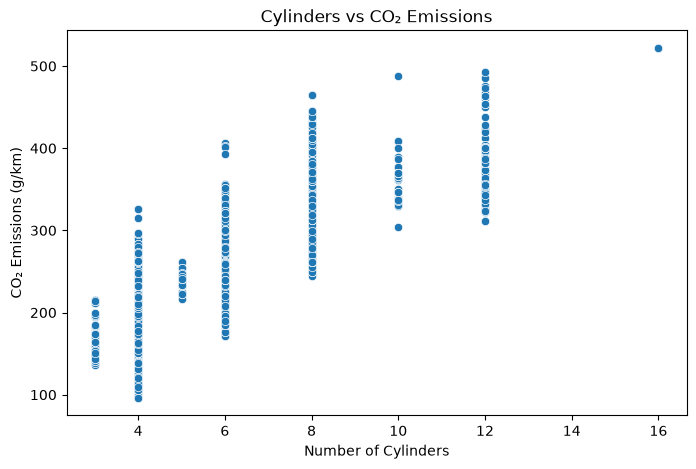

In [23]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Cylinders",
    y="CO2 Emissions(g/km)"
)

plt.title("Cylinders vs CO₂ Emissions")
plt.xlabel("Number of Cylinders")
plt.ylabel("CO₂ Emissions (g/km)")
plt.show()

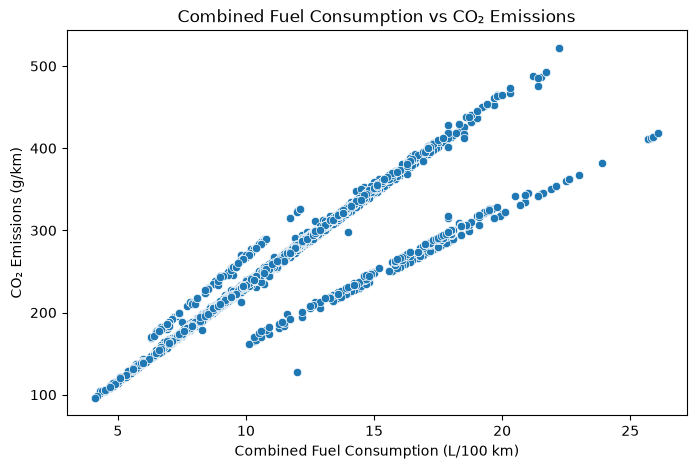

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Fuel Consumption Comb (L/100 km)",
    y="CO2 Emissions(g/km)"
)

plt.title("Combined Fuel Consumption vs CO₂ Emissions")
plt.xlabel("Combined Fuel Consumption (L/100 km)")
plt.ylabel("CO₂ Emissions (g/km)")
plt.show()

In [25]:
print("Duplicate rows before removal:", df.duplicated().sum())

Duplicate rows before removal: 1103


In [26]:
df = df.drop_duplicates().reset_index(drop=True)

In [27]:
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (6282, 12)


In [28]:
df.isnull().sum()

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
features = [
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (L/100 km)",
    "Fuel Consumption Comb (mpg)"
]

X = df[features]
y = df["CO2 Emissions(g/km)"]

In [31]:
X.head()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
0,2.0,4,9.9,6.7,8.5,33
1,2.4,4,11.2,7.7,9.6,29
2,1.5,4,6.0,5.8,5.9,48
3,3.5,6,12.7,9.1,11.1,25
4,3.5,6,12.1,8.7,10.6,27


In [32]:
y.head()

0    196
1    221
2    136
3    255
4    244
Name: CO2 Emissions(g/km), dtype: int64

In [33]:
print(X.shape)
print(y.shape)

(6282, 6)
(6282,)


## Train-Test Split

The cleaned dataset is divided into training and testing sets. The training set is used to build the regression model, while the testing set is used to evaluate how well the model performs on unseen data.


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [35]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5025, 6)
Testing features: (1257, 6)
Training target: (5025,)
Testing target: (1257,)


In [36]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 5.67, 7.08, 3.26, 6.56,-3.98,-3.48]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Engine Size(L)','Cylinders','Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)','Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,232
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [37]:
y_pred = model.predict(X_test)

In [38]:
print(X_train.shape)
print(X_test.shape)

(5025, 6)
(1257, 6)


In [40]:
comparison = pd.DataFrame({
    "Actual CO2": y_test.values[:10],
    "Predicted CO2": y_pred[:10]
})

comparison

,Actual CO2,Predicted CO2
0,322,270.162083
1,242,250.710457
2,300,283.871198
3,275,273.788148
4,245,252.611901
5,220,220.541248
6,284,272.902848
7,270,243.204786
8,274,270.912901
9,306,309.399323


In [41]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Engine Size(L),5.667746
1,Cylinders,7.079440
2,Fuel Consumption City (L/100 km),3.259889
3,Fuel Consumption Hwy (L/100 km),6.564028
4,Fuel Consumption Comb (L/100 km),-3.981782
5,Fuel Consumption Comb (mpg),-3.478207


In [42]:
print("Intercept:", model.intercept_)

Intercept: 231.96578811714892


## Model Evaluation

The performance of the Linear Regression model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. These metrics help measure the difference between the actual CO₂ emissions and the values predicted by the model.


In [43]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 12.102140638722762
Mean Squared Error (MSE): 368.3228586622492
Root Mean Squared Error (RMSE): 19.191739333949105
R² Score: 0.8979353672510262


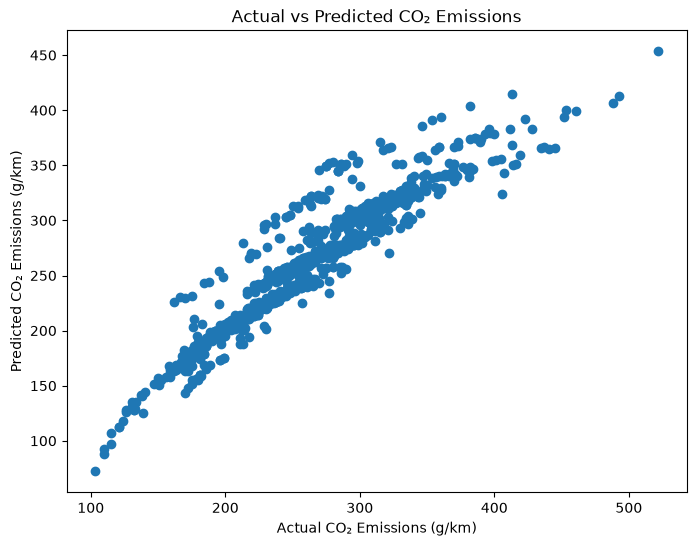

In [44]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual CO₂ Emissions (g/km)")
plt.ylabel("Predicted CO₂ Emissions (g/km)")
plt.title("Actual vs Predicted CO₂ Emissions")

plt.show()

In [45]:
residuals = y_test - y_pred

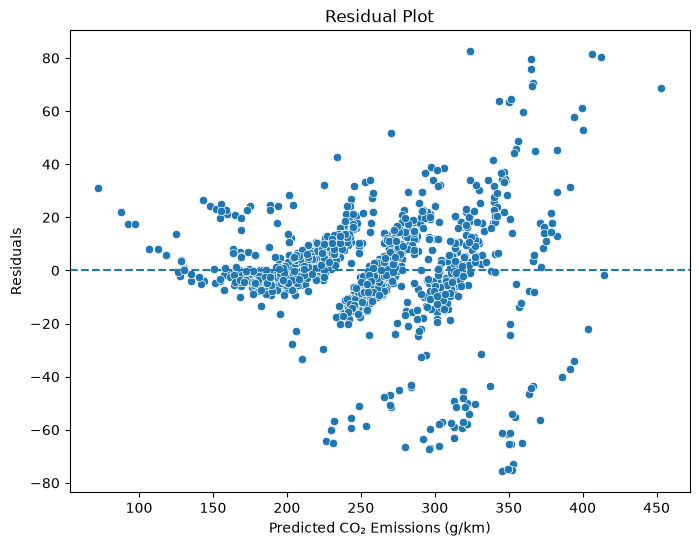

In [46]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted CO₂ Emissions (g/km)")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

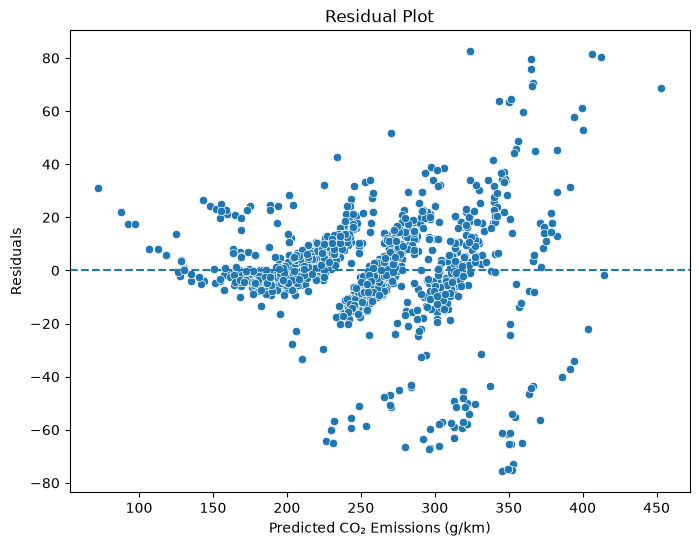

In [47]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted CO₂ Emissions (g/km)")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [48]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
1,Cylinders,7.079440
3,Fuel Consumption Hwy (L/100 km),6.564028
0,Engine Size(L),5.667746
2,Fuel Consumption City (L/100 km),3.259889
5,Fuel Consumption Comb (mpg),-3.478207
4,Fuel Consumption Comb (L/100 km),-3.981782


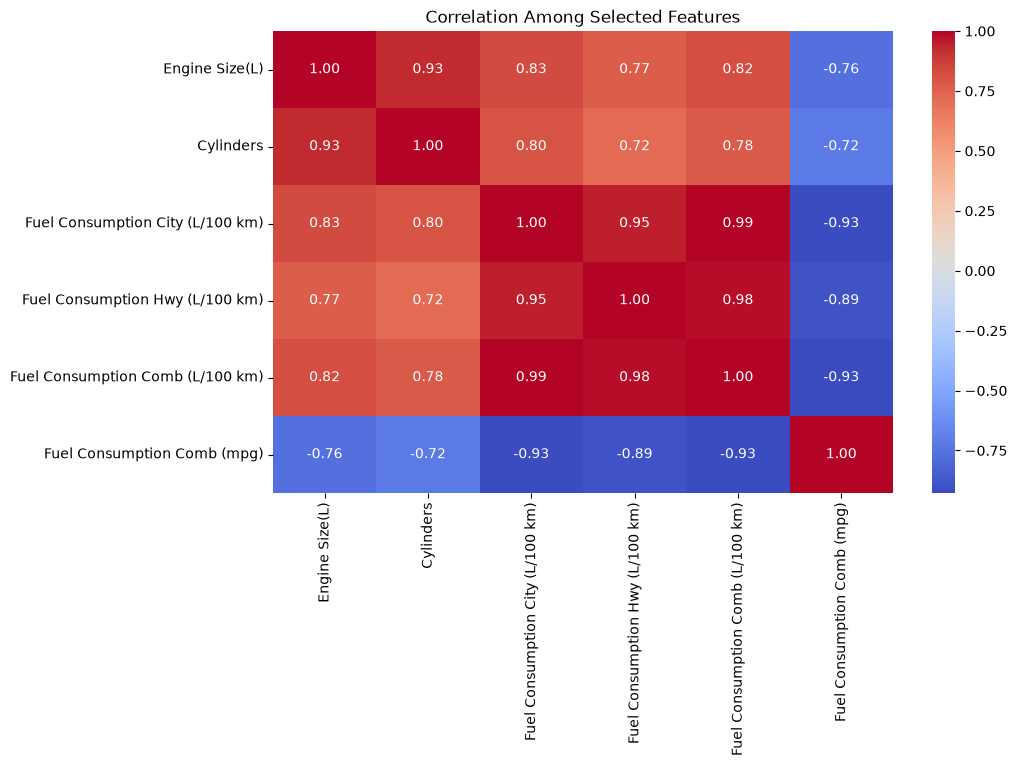

In [49]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Among Selected Features")
plt.show()